#**Employee Churn Analysis**

> This project is designed to pinpoint employees who may be contemplating departure. By leveraging Machine Learning models, the report enables Human Resources team to engage proactively and address individual employee concerns with precision.




## **1. Data Ingestion**

In [54]:
import pandas as pd
file_path = '/content/tbl_hr_data.csv'
df = pd.read_csv(file_path)
file_path2 = '/content/tbl_new_employees.csv'
df2 = pd.read_csv(file_path2)

# Data quick check
print(f"Historical cohort dataset shape: {df.shape}")
print(f"New hire prediction dataset shape: {df2.shape}")

Historical cohort dataset shape: (15004, 11)
New hire prediction dataset shape: (100, 11)


In [55]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.38,0.53,2.0,157,3.0,0.0,1,0,sales,low,EMP00001
1,0.80,0.86,5.0,262,6.0,0.0,1,0,sales,medium,EMP00002
2,0.11,0.88,7.0,272,4.0,0.0,1,0,sales,medium,EMP00003
3,0.72,0.87,5.0,223,5.0,0.0,1,0,sales,low,EMP00004
4,0.37,0.52,2.0,159,3.0,0.0,1,0,sales,low,EMP00005


## **2. Exploratory Data Analysis**

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set theme and styling defaults
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 12
})

# Create a dataframe for charts
plot_df = df.copy()
plot_df['Turnover_Status'] = plot_df['Quit_the_Company'].map({0: 'Retained', 1: 'Left'})

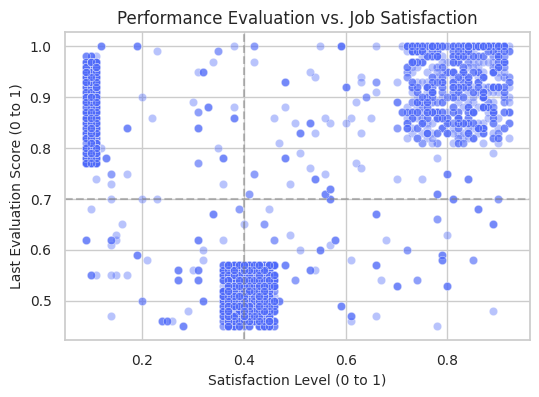

In [57]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=plot_df[plot_df['Quit_the_Company'] == 1],
    x='satisfaction_level',
    y='last_evaluation',
    alpha=0.4,
    color='#4F6AF9'
)
plt.title('Performance Evaluation vs. Job Satisfaction')
plt.xlabel('Satisfaction Level (0 to 1)')
plt.ylabel('Last Evaluation Score (0 to 1)')
plt.axvline(x=0.4, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)
plt.show()

The scatter plot maps the relationship between **Satisfaction Level** and **Last Evaluation Score** of employees who have left the company.<br>
From the chart, employee turnover intensifies into three distinct clusters:<br>
Cluster 1: High performance evaluation scores (>0.75) with extremely low satisfaction levels (<0.2) => This is the **burnout/overworked** group.<br>
Cluster 2: Both low performance scores (<0.6) and low satisfaction levels (0.35 to 0.45) => This group represents employees who **struggled** to align with their job roles.<br>
Cluster 3: High performance evaluation scores (>0.8) combined with high job satisfaction levels (>0.8) => These employees genuinely satisfy with the organization and perform well, yet they still leave, mostly for **better opportinities**.

<Figure size 800x400 with 0 Axes>

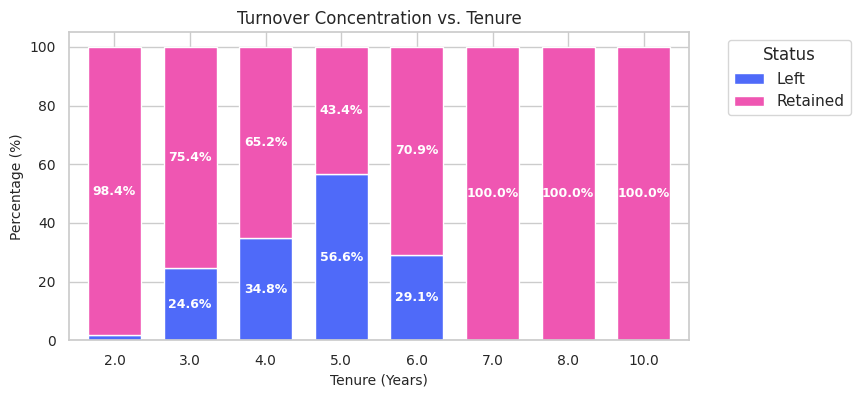

In [58]:
plt.figure(figsize=(8, 4))
tenure_churn = pd.crosstab(plot_df['time_spend_company'], plot_df['Turnover_Status'], normalize='index') * 100

ax = tenure_churn.plot(kind='bar', stacked=True, color=['#4F6AF9', '#EF56B2'], figsize=(8, 4), width=0.7)
plt.title('Turnover Concentration vs. Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Percentage labels
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 5:
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center', color='white', fontweight='bold', fontsize=9)
plt.show()

The bar chart shows the ratio of employees who stayed and those who departed across different years of tenure at the company.<br>
The data reveals that attrition risk peaks aggressively in the middle years before dropping to zero for long-term employees.<br> By **years 3 to 5**, employees have mastered their roles. If they do not see a clear path to internal promotion or a significant raise, they will consider looking for another advancement.

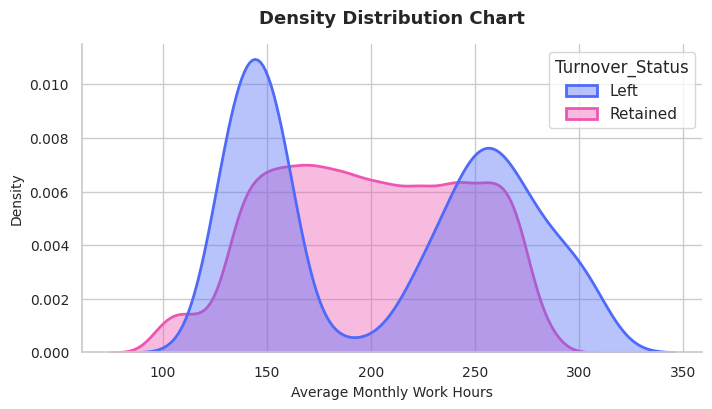

In [59]:
plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=plot_df,
    x='average_montly_hours',
    hue='Turnover_Status',
    fill=True,
    common_norm=False,
    palette=['#4F6AF9', '#EF56B2'],
    alpha=0.4,
    linewidth=2
)

plt.title('Density Distribution Chart', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Average Monthly Work Hours')
plt.ylabel('Density')
sns.despine()
plt.show()

This plot visualizes the distribution of Average Monthly Work Hours for employees. The two distinct peaks for churned employees prove that employees don't just leave when they are **overworked**. They also leave when they are **under-utilized**.

## **3. Distribution Analysis and Multicollinearity Check**

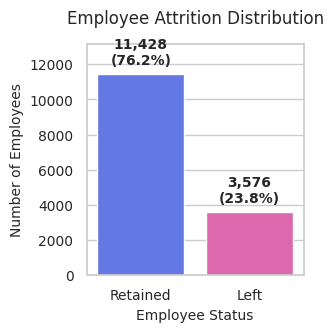

In [60]:
# Calculate count and percentage
target_counts = plot_df['Turnover_Status'].value_counts()
target_pct = plot_df['Turnover_Status'].value_counts(normalize=True) * 100

# Plotting the target class imbalance
plt.figure(figsize=(2.8, 3))
ax = sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    hue=target_counts.index,
    palette=['#4F6AF9', '#EF56B2'],
    legend=False
)

for i, p in enumerate(ax.patches):
    height = p.get_height()
    pct = target_pct.iloc[i]
    ax.annotate(
        f'{int(height):,}\n({pct:.1f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontweight='bold'
    )

plt.title('Employee Attrition Distribution', pad=15)
plt.ylabel('Number of Employees')
plt.xlabel('Employee Status')
plt.ylim(0, max(target_counts.values) * 1.15)
plt.show()

From the above chart, 76.2% of the employees remain with the company, while the remaining 23.8% represent employees who have left the organization.<br>
This employee churn dataset is naturally imbalanced, suggesting the use of **class_weight='balanced'** parameter in tree-based machine learning models to penalize minority misclassifications.

In [61]:
import numpy as np

X_preliminary = df.drop(columns=['Quit_the_Company', 'employee_id'], errors='ignore')
num_cols = X_preliminary.select_dtypes(exclude=['object', 'category']).columns

# Screen for highly collinear numerical features (> 0.85 correlation coefficient)
correlation_matrix = df[num_cols].corr()
high_corr = np.where(np.abs(correlation_matrix) > 0.85)
high_corr_list = [(correlation_matrix.index[x], correlation_matrix.columns[y])
                  for x, y in zip(*high_corr) if x != y and x < y]
print(f"Collinear feature pairs threatening permutation accuracy: {high_corr_list}")

Collinear feature pairs threatening permutation accuracy: []


Independent variables are not highly correlated with each other.

##**4. Data Preprocessing**

In [62]:
# Set up final working datasets
X = X_preliminary.copy()
y = df['Quit_the_Company']

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Separate categorical and numerical columns
cat_features = X.select_dtypes(include=['object', 'category']).columns
num_features = X.select_dtypes(exclude=['object', 'category']).columns

# Build structured preprocessing layers
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_features)
])

## **5. Model Selection**

In [64]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Use class_weight='balanced' parameter to prevent minority group classification bias
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=123, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=123, class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(random_state=123, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=123)
}

results = []
for name, model in models.items():
    pipeline = Pipeline([('pre', preprocessor), ('model', model)])
    # Optimization scoring parameter shifted from accuracy to roc_auc
    score = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc').mean()
    results.append([name, score])

results_df = pd.DataFrame(results, columns=['Model', 'ROC-AUC Score']).sort_values('ROC-AUC Score', ascending=False)
print(results_df)

                 Model  ROC-AUC Score
2        Random Forest       0.993398
3          Extra Trees       0.992136
4    Gradient Boosting       0.987142
1        Decision Tree       0.974533
0  Logistic Regression       0.804229


Because the data is imbalanced, the chosen optimization metric is **ROC-AUC** rather than Accuracy to protect model sensitivity toward the minority class.<br>
The model with highest ROC-AUC score is **Random Forest**.

## **6. Model training**

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import permutation_importance

# Split data to run strict model out-of-sample error diagnostics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

best_model = RandomForestClassifier(random_state=123, class_weight='balanced')
diagnostic_pipeline = Pipeline([('pre', preprocessor), ('model', best_model)])
diagnostic_pipeline.fit(X_train, y_train)

test_preds = diagnostic_pipeline.predict(X_test)
test_probs = diagnostic_pipeline.predict_proba(X_test)[:, 1]

print("Classification Metrics on Unseen Test Partition:")
print(classification_report(y_test, test_preds))
print(f"Unseen Test ROC-AUC Score: {roc_auc_score(y_test, test_probs)}")

# Run permutation evaluation on test subset to eliminate training-data memory bias
r = permutation_importance(diagnostic_pipeline, X_test, y_test, n_repeats=5, random_state=123)
feature_table = pd.DataFrame({'feature': X.columns, 'importance': r.importances_mean}).sort_values('importance', ascending=False)

Classification Metrics on Unseen Test Partition:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       0.99      0.97      0.98       715

    accuracy                           0.99      3001
   macro avg       0.99      0.98      0.99      3001
weighted avg       0.99      0.99      0.99      3001

Unseen Test ROC-AUC Score: 0.9946594962342994


In [67]:
# Refit on 100% of available historical data
final_pipeline = Pipeline([('pre', preprocessor), ('model', RandomForestClassifier(random_state=123, class_weight='balanced'))])
final_pipeline.fit(X, y)

df['Prediction'] = final_pipeline.predict(X)

# Enforce explicit matrix column alignment on new features before forward scoring
X_new = df2[X.columns]
df2['Prediction'] = final_pipeline.predict(X_new)

In [66]:
feature_table

,feature,importance
0,satisfaction_level,0.185671
2,number_project,0.118427
1,last_evaluation,0.117561
3,average_montly_hours,0.117561
4,time_spend_company,0.097301
8,salary,0.009530
7,Departments,0.009397
5,Work_accident,0.002466
6,promotion_last_5years,0.000200


This predictive analysis, utilizing Random Forest model, has determined that employee **job satisfaction** is the paramount predictor in forecasting retention. The analysis reveals a pattern: employees with a substantial number of **completed projects**, **high performance** evaluations and **moderate working hours** are more inclined to remain with the organization.